In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import optuna
import tensorflow as tf

import warnings

c:\Users\Marwa\anaconda3\envs\cc_abs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../data/CORCCACBS.csv')


a = df.groupby(df['date'])['value'].mean().round(2)#.reset_index()
b = pd.to_datetime(df['date'].unique())
df= pd.DataFrame({
    'date':b,
    'value':a.values
})
df = df.set_index('date')


def traintestsplit(df):
    train = df.loc[:'2015']
    val = df.loc['2016':'2019']
    test = df.loc['2020':]

    return train,val ,test

train_set, val_set, test_set = traintestsplit(df)

In [11]:
print(len(train_set),len(val_set))

124 16


Creating our timeseries data set via Tensorflow

GradDescent requires IID, shuffling training windows (not the contents)
- so the model's weight doesn't update / get biased toward whatever pattern is most recent!

In [4]:
seq_length = 8

train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    train_set,targets = train_set[seq_length:],#targets are 3 steps into the future
    sequence_length=seq_length, batch_size=4,shuffle = True, seed=11
    )

val_dataset = tf.keras.utils.timeseries_dataset_from_array(
    val_set, targets=val_set[seq_length:], sequence_length=seq_length, batch_size=4, shuffle= True, seed=11
)

test_dataset = tf.keras.utils.timeseries_dataset_from_array(
    test_set, targets=test_set[seq_length:], sequence_length=seq_length, batch_size=4,shuffle= True, seed=11
)

Trying a basic linear model first: Using Huber Loss

In [5]:
tf.random.set_seed(11)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=[seq_length])
])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_mae',
                                                     patience=50,
                                                     restore_best_weights=True)

opt = tf.keras.optimizers.SGD(learning_rate=.02,momentum=0.9)


model.compile(loss=tf.keras.losses.Huber(),optimizer=opt,metrics=['mae'])


history = model.fit(train_dataset, validation_data=val_dataset, epochs=500,
                    callbacks=[early_stopping_cb])

Epoch 1/500


c:\Users\Marwa\anaconda3\envs\cc_abs\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.5233 - mae: 8.0186 - val_loss: 3.2450 - val_mae: 3.7450
Epoch 2/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7791 - mae: 3.2653 - val_loss: 5.2141 - val_mae: 5.7141
Epoch 3/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8519 - mae: 4.3343 - val_loss: 3.9096 - val_mae: 4.4096
Epoch 4/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8933 - mae: 3.3770 - val_loss: 0.7939 - val_mae: 1.2939
Epoch 5/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1856 - mae: 3.6582 - val_loss: 2.5860 - val_mae: 3.0860
Epoch 6/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0187 - mae: 4.4948 - val_loss: 0.4246 - val_mae: 0.9192
Epoch 7/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9195 - mae: 1.3578 - val_loss: 0.0065 - val_mae: 0.0740
Epoch 8/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0492 - mae: 2.5023 - val_loss: 0.0661 - val_mae: 0.3174
Epoch 9/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8666 - mae: 2.

Best epoch: 7, Val MAE: 0.0740


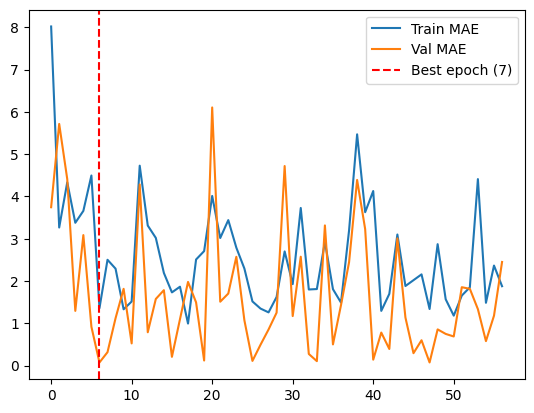

In [6]:
best_val_mae = min(history.history['val_mae'])
best_epoch = history.history['val_mae'].index(best_val_mae) + 1  # +1 since epochs start at 1
print(f"Best epoch: {best_epoch}, Val MAE: {best_val_mae:.4f}")

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.legend()
plt.show()

Using a simple RNN

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32,input_shape=[None,1]), #Univariate sequence of any length 
    tf.keras.layers.Dense(1) #no activation function by default
])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_mae',
                                                     patience=50,
                                                     restore_best_weights=True)

opt = tf.keras.optimizers.SGD(learning_rate=.02,momentum=0.9)


model.compile(loss=tf.keras.losses.Huber(),optimizer=opt,metrics=['mae'])


history = model.fit(train_dataset, validation_data=val_dataset, epochs=500,
                    callbacks=[early_stopping_cb])

Epoch 1/500


c:\Users\Marwa\anaconda3\envs\cc_abs\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.8592 - mae: 1.2846 - val_loss: 0.1944 - val_mae: 0.6227
Epoch 2/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3514 - mae: 0.7099 - val_loss: 0.0746 - val_mae: 0.3847
Epoch 3/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2722 - mae: 0.5875 - val_loss: 8.7799e-04 - val_mae: 0.0325
Epoch 4/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3222 - mae: 0.6587 - val_loss: 0.0332 - val_mae: 0.2543
Epoch 5/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3729 - mae: 0.7186 - val_loss: 0.0497 - val_mae: 0.3135
Epoch 6/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2590 - mae: 0.5781 - val_loss: 0.5483 - val_mae: 1.0483
Epoch 7/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2667 - mae: 0.6118 - val_loss: 0.0180 - val_mae: 0.1865
Epoch 8/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3439 - mae: 0.7025 - val_loss: 0.1220 - val_mae: 0.4925
Epoch 9/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2214 - mae

Best epoch: 3, Val MAE: 0.0325


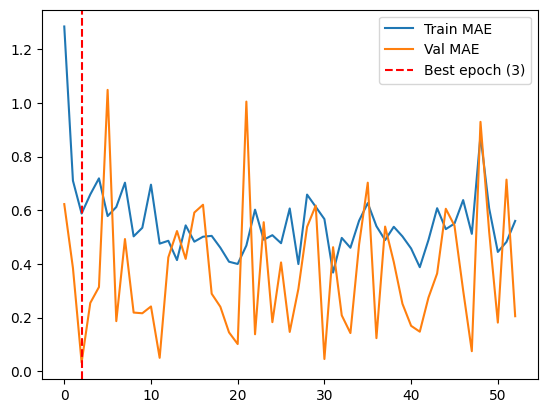

In [10]:
best_val_mae = min(history.history['val_mae'])
best_epoch = history.history['val_mae'].index(best_val_mae) + 1  # +1 since epochs start at 1
print(f"Best epoch: {best_epoch}, Val MAE: {best_val_mae:.4f}")

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.legend()
plt.show()

## Not enough data

Biggest tell: Our train MAE is higher than our Validation, its also very erratic... we'll have to use simpler models as RNN's will require a much higher volume of data